In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
fg = pd.read_csv("fear_greed_index.csv")
ht = pd.read_csv("historical_data.csv")

In [3]:
fg.shape

(2644, 4)

In [4]:
ht.shape

(211224, 16)

In [5]:
fg.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [6]:
ht.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [7]:
fg.duplicated().sum()

np.int64(0)

In [8]:
ht.duplicated().sum()

np.int64(0)

In [9]:
fg['date']= pd.to_datetime(fg['date'])

In [10]:
from datetime import datetime
ht['date']=ht['Timestamp IST'].apply(lambda x: datetime.strptime(x,'%d-%m-%Y %H:%M').date())
ht['date']=pd.to_datetime(ht['date'])

In [11]:
df = ht.merge(fg[['date','value','classification']],on='date',how='left')


In [12]:
df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,80.0,Extreme Greed


In [13]:
#Daily PnL per Account
daily_pnl=df.groupby(['Account','date'])['Closed PnL'].sum().reset_index(name = "Daily_PnL")
daily_pnl

,Account,date,Daily_PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.000000
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.000000
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.000000
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.100000
...,...,...,...
2336,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-27,1709.194807
2337,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-28,4008.588908
2338,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-29,8561.771838
2339,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-30,2520.773814


In [14]:
#win_rate
df['Profit']= (df["Closed PnL"]>0)

In [15]:
win_rate = df.groupby('Account')['Profit'].mean().reset_index(name = "Win_Rate")
win_rate

,Account,Win_Rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.442720
2,0x271b280974205ca63b716753467d5a371de622ab,0.301917
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.438585
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.519914
5,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.455215
6,0x39cef799f8b69da1995852eea189df24eb5cae3c,0.327668
7,0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,0.475904
8,0x420ab45e0bd8863569a5efbb9c05d91f40624641,0.234987
9,0x430f09841d65beb3f27765503d0f850b8bce7713,0.484236


In [16]:
#average trade size
avg_trade_size = df.groupby('Account')['Size USD'].mean().reset_index(name="Average_Trade_Size")
avg_trade_size

,Account,Average_Trade_Size
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.894782
5,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,1729.941104
6,0x39cef799f8b69da1995852eea189df24eb5cae3c,4790.575486
7,0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,3445.471265
8,0x420ab45e0bd8863569a5efbb9c05d91f40624641,5189.367128
9,0x430f09841d65beb3f27765503d0f850b8bce7713,2397.824753


In [17]:
#Trades per day
Trades_per_day = df.groupby(['Account','date']).size().reset_index(name="Trades_per_day")
Trades_per_day

,Account,date,Trades_per_day
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,177
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,68
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,40
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,12
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,27
...,...,...,...
2336,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-27,82
2337,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-28,430
2338,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-29,902
2339,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-30,75


In [18]:
#long short ratio
side_count = df.groupby('Account')['Side'].value_counts().unstack(fill_value=0)
side_count['Long_Short_Ratio']= side_count['BUY']/side_count['SELL']
Long_Short_Ratio = side_count['Long_Short_Ratio'].reset_index()
Long_Short_Ratio

,Account,Long_Short_Ratio
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.812055
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.723077
2,0x271b280974205ca63b716753467d5a371de622ab,0.698172
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.013158
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.572330
5,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.287520
6,0x39cef799f8b69da1995852eea189df24eb5cae3c,0.849047
7,0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,1.049383
8,0x420ab45e0bd8863569a5efbb9c05d91f40624641,0.358156
9,0x430f09841d65beb3f27765503d0f850b8bce7713,0.322995


In [19]:
# Sentiment Performance PnL Winrate
perf =df.groupby('classification')[['Closed PnL','Profit']].mean()
perf

,Closed PnL,Profit
classification,,
Extreme Fear,34.537862,0.370607
Extreme Greed,67.892861,0.464943
Fear,54.290400,0.420768
Greed,42.743559,0.384828
Neutral,34.307718,0.396991


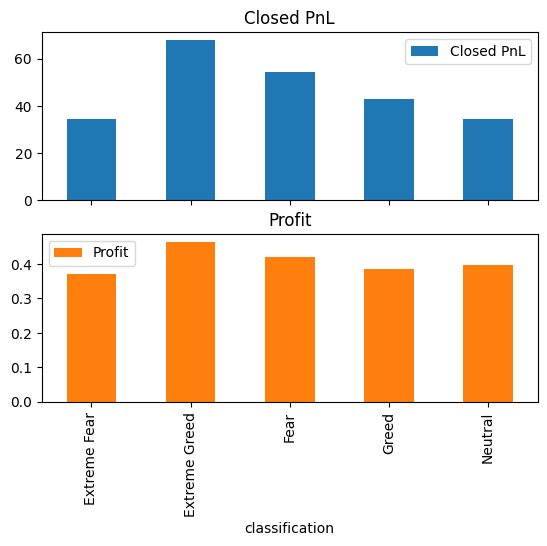

In [20]:
perf.plot(kind='bar',subplots = True)
plt.show()
#Extreme Greed days shows the highest average PnL(67.89) while Extreme Fear days shows lowest(34.54).
# Win rate follows similar pattern Extreme Greed(0.46) vs Extreme Fear(0.37)
#Traders perform better in profitability and consistency during high greed sentiment periods.

In [ ]:
#DO trader change behavior on sentiment?
sizes =df.groupby("classification")["Size USD"].mean().reset_index()
sizes
#Yes ,On Fear days traders place larger position sizes(avg $7816) compared to Greed days (avg $5736)

,classification,Size USD
0,Extreme Fear,5349.731843
1,Extreme Greed,3112.251565
2,Fear,7816.109931
3,Greed,5736.884375
4,Neutral,4782.732661


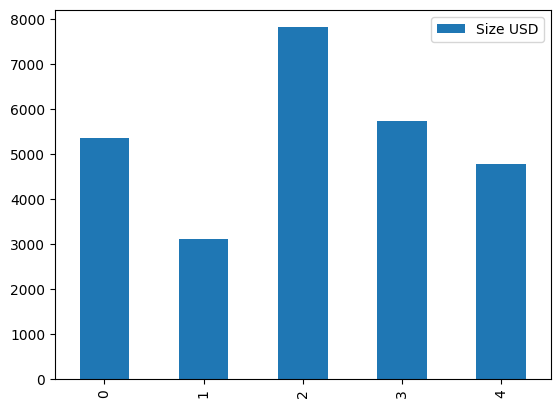

In [23]:
sizes.plot(kind='bar')
plt.show()

In [24]:
Trade_N =df.groupby("classification").size().reset_index(name = "Trades done")
Trade_N
#Trader trades more frequently on Fear days(61837) compared to Greed days(50303)

,classification,Trades done
0,Extreme Fear,21400
1,Extreme Greed,39992
2,Fear,61837
3,Greed,50303
4,Neutral,37686


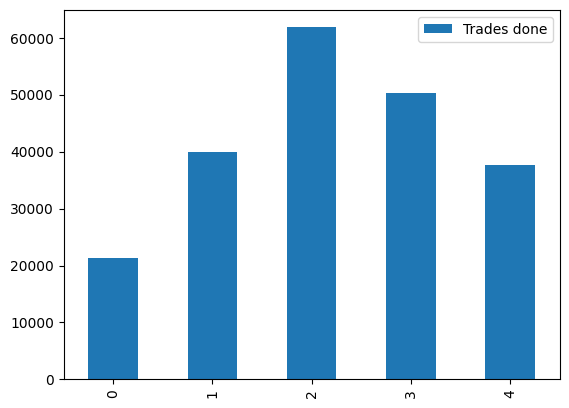

In [25]:
Trade_N.plot(kind='bar')
plt.show()

In [26]:
Ratio=df.groupby('classification')['Side'].value_counts().unstack(fill_value=0)
Ratio
#On Fear days both Buy and Sell are highest(30270 and 31567) and on Greed days they are lower(24576 and 25727)

Side,BUY,SELL
classification,,
Extreme Fear,10935,10465
Extreme Greed,17940,22052
Fear,30270,31567
Greed,24576,25727
Neutral,18969,18717


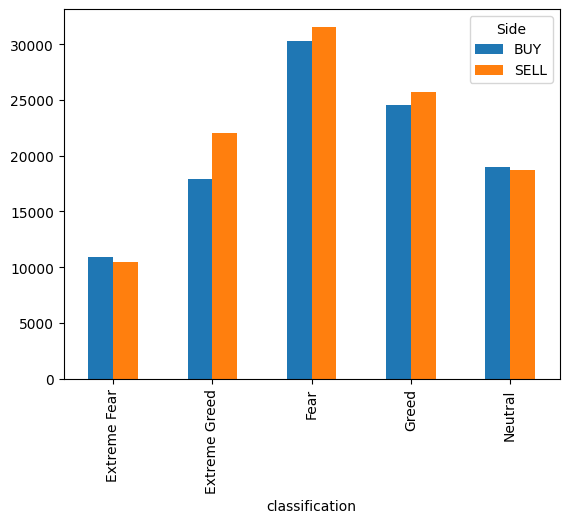

In [27]:
Ratio.plot(kind='bar')
plt.show()

In [28]:
#Yes,With evidence we can see that the Traders do change behavior based on sentiment
# (Trade frequency,long/short bias,position sizes)

In [68]:
#Segment 1(Frequent vs Infrequent Traders)
total_trades = Trades_per_day.groupby('Account')['Trades_per_day'].sum().reset_index()
median_trades=total_trades['Trades_per_day'].median()
total_trades['segment']= np.where(total_trades['Trades_per_day']>=median_trades,'Frequent','Infrequent')
total_trades.groupby('segment')['Trades_per_day'].mean().reset_index()

,segment,Trades_per_day
0,Frequent,11684.8125
1,Infrequent,1516.6875


In [ ]:
#Segment 2 (Winners vs Losers)
median_wr = win_rate['Win_Rate'].median()
win_rate['segment']=np.where(win_rate['Win_Rate']>=median_wr,'Winner','Loser')
win_rate.groupby('segment')['Win_Rate'].mean().reset_index()

,segment,Win_Rate
0,Loser,0.323940
1,Winner,0.482185


In [72]:
#Strategy based on findings
#Strategy 1 - During Fear sentiments, traders should reduce position size to minimize losses as on Fear days traders place larger positions but wins less.
#Strategy 2- Infrequent traders should increase activity during Extreme Fear days where PnL is highest.
